# 34 — `labels`

`Map.labels` writes **one string per feature**, taken from an attribute column. It is the layer that turns a map
of shapes into one a reader can name things on — and the layer most likely to ruin a figure if used carelessly,
because text does not shrink, overlap gracefully, or stay legible over a busy background.

By the end you will be able to label features from a column, size and colour the text, keep it readable with a
halo, nudge it clear with an offset, and — most importantly — choose what *not* to label.

API: [`Map.labels`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

Two real layers: Germany's 16 states (**geoBoundaries**, one `shapeName` per polygon) and the 2,320 Heidelberg
**OpenStreetMap** roads (2,242 of them named). One polygon case and one line case, which behave differently
enough to be worth seeing both.

In [2]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
roads = FeatureCollection.read_file(str(DATA / "heidelberg_roads.geojson"))
print(f"{len(states)} states; {roads['name'].notna().sum()} of {len(roads)} roads named")
print("longest state name:", max(states["shapeName"], key=len))

16 states; 2242 of 2320 roads named
longest state name: Mecklenburg-Vorpommern


## Quickstart — labelling polygons

`labels(features, column)` places each string at its feature's anchor — the centroid, for a polygon. The default
is white text with a black halo, the combination that survives an arbitrary background.

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\base\points.py:222: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = geom.centroid


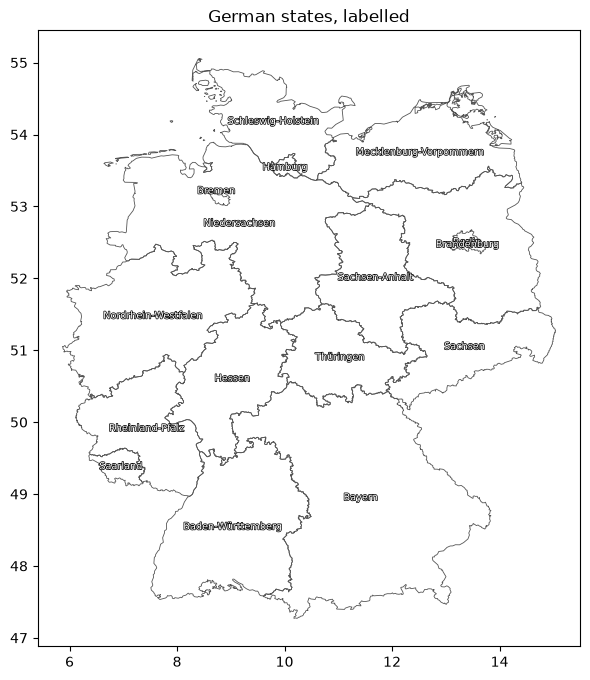

In [3]:
m = Map(crs=4326, figsize=(7, 8))
m.polygons(states, edgecolor="#555555", linewidth=0.6)
m.labels(states, "shapeName", text_size=7)
m.set_title("German states, labelled")
m.fig;

`text_size=7` rather than the default 12 is doing real work: at 12 the long names —
*Mecklenburg-Vorpommern*, *Nordrhein-Westfalen* — collide with their neighbours. Labelling is always a
negotiation with available space.

## Styling the text

Text colour, halo colour and halo width are separate arguments, so a label can be tuned to its background rather
than to a theme.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute holding the text | a string column |
| `text_size` | font size in points | `12.0` default; drop it when labels crowd |
| `color` | text colour | `"#ffffff"` default |
| `halo_color` | outline drawn behind the glyphs | `"#000000"` default |
| `halo_width` | outline thickness | `1.0` default; `0` disables |
| `offset` | `(dx, dy)` shift in points, to clear the feature | `None` |

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\base\points.py:222: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = geom.centroid


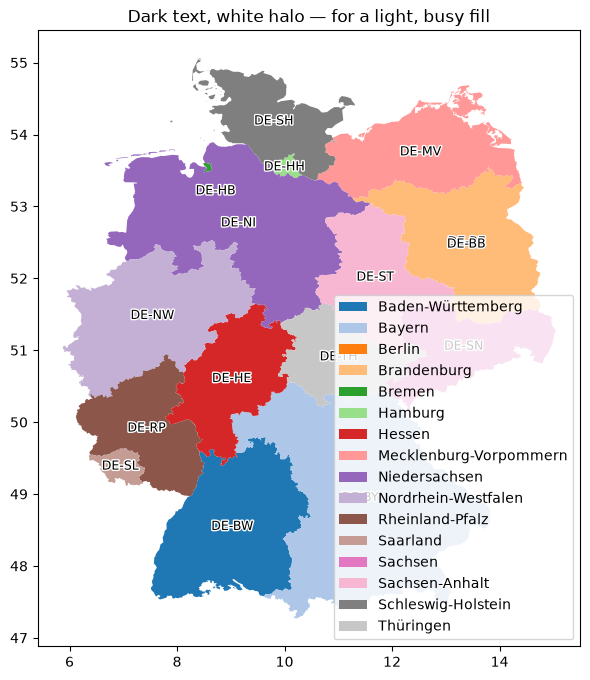

In [4]:
m = Map(crs=4326, figsize=(7, 8))
m.choropleth(states, "shapeName", scheme="categorical", cmap="tab20", legend=False)
m.labels(states, "shapeISO", text_size=9, color="black", halo_color="white", halo_width=2.0)
m.set_title("Dark text, white halo — for a light, busy fill")
m.fig;

Over a pale multi-colour fill the default white-on-black inverts badly, so black text in a white halo reads
better. The halo is what makes either choice work: without it the glyphs vanish wherever they cross a fill of
similar lightness. Switching to the short `shapeISO` code is the other half of the fix — a shorter string is
often worth more than any styling argument.

## Labelling lines, and choosing what to leave out

2,242 named roads is far too many to label. Filtering to the arterials — and then to one label per street name —
is what makes the figure readable, and it matters more than every style argument combined.

In [5]:
arterials = roads[(roads["klass"].isin(["trunk", "primary"])) & roads["name"].notna()]
named = FeatureCollection(arterials.drop_duplicates("name"))
print(f"{len(arterials)} arterial segments -> {len(named)} distinct street names")

384 arterial segments -> 22 distinct street names


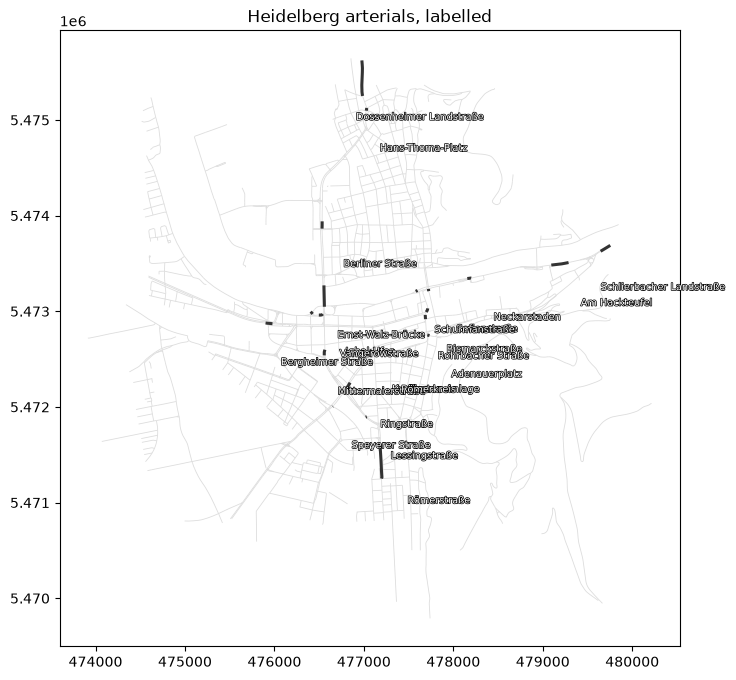

In [6]:
m = Map(crs=UTM32, figsize=(8, 8))
m.lines(roads, color="#dddddd", width=0.6)
m.lines(named, color="#333333", width=2.2)
m.labels(named, "name", text_size=7, offset=(6, 4))
m.set_title("Heidelberg arterials, labelled")
m.fig;

The full network stays as pale context, the arterials are picked out in dark grey, and only those carry a name —
offset up and to the right so the text does not sit on the line it belongs to. Try it without the
`drop_duplicates` and the same street's name appears a dozen times along its length, which is the most common
way a labelled line map fails.

## Takeaway

- `labels(features, column)` writes one string per feature at its anchor — polygon centroid, or the line itself.
- `text_size` is usually the first thing to reduce; the default 12 crowds quickly.
- The **halo** keeps text legible over an unknown background; match `color`/`halo_color` to the fill.
- `offset` moves labels clear of the feature.
- Filtering — fewer features, shorter strings, one label per name — beats any styling argument.

That completes the plot gallery. For scene-level machinery — layers, insets, multi-panel figures — see
[`15_layer_management`](../15_layer_management.ipynb) onward.